### Plot figures for Figure 3 A - C and Supplementary figure 3

In [24]:
import matplotlib.pyplot as plt 
import numpy as np
import pandas as pd 
import ast

In [6]:
path_csv_file = "/Users/natalibarroszulaica/Desktop/OBI/HUMAN_CORTEX/PAPERS_ON_GOING/CONNECTIVITY_PAPER/code/ConnectomeUtilities/connection_probability_results.csv"

In [76]:
# Check what is inside the csv file
data = pd.read_csv(path_csv_file)
data.head()

,Structural_human,Functional_human,E_to_T_human,T_to_T_human,E_to_E_human,T_to_E_human,Structural_rat,Functional_rat,E_to_T_rat,T_to_T_rat,E_to_E_rat,T_to_E_rat,E_to_T_HC_RD,T_to_T_HC_RD,E_to_E_HC_RD,T_to_E_HC_RD,HC_RD
0,"{'p_conn_dist': array([7.33860106e-01, 6.00110...","{'p_conn_dist': array([2.25489192e-01, 1.19884...","{'p_conn_dist': array([1.23628847e-01, 1.00762...","{'p_conn_dist': array([4.16285880e-01, 2.76468...","{'p_conn_dist': array([7.20338079e-02, 5.87275...","{'p_conn_dist': array([1.62071624e-01, 9.34934...","{'p_conn_dist': array([8.37547383e-01, 6.85219...","{'p_conn_dist': array([9.46677283e-02, 5.53315...","{'p_conn_dist': array([5.25254519e-02, 4.30058...","{'p_conn_dist': array([2.07068321e-01, 1.30611...","{'p_conn_dist': array([3.90442192e-02, 3.19317...","{'p_conn_dist': array([7.63938748e-02, 4.66151...","{'p_conn_dist': array([0.03747854, 0.02963014,...","{'p_conn_dist': array([0.15147003, 0.10812095,...","{'p_conn_dist': array([0.03540999, 0.0277971 ,...","{'p_conn_dist': array([0.05211058, 0.03687913,...","{'p_conn_dist': array([0.82651046, 0.64856319,..."
1,{'model': 'exp_model_scale * np.exp(-exp_model...,{'model': 'exp_model_scale * np.exp(-exp_model...,{'model': 'exp_model_scale * np.exp(-exp_model...,{'model': 'exp_model_scale * np.exp(-exp_model...,{'model': 'exp_model_scale * np.exp(-exp_model...,{'model': 'exp_model_scale * np.exp(-exp_model...,{'model': 'exp_model_scale * np.exp(-exp_model...,{'model': 'exp_model_scale * np.exp(-exp_model...,{'model': 'exp_model_scale * np.exp(-exp_model...,{'model': 'exp_model_scale * np.exp(-exp_model...,{'model': 'exp_model_scale * np.exp(-exp_model...,{'model': 'exp_model_scale * np.exp(-exp_model...,{'model': 'exp_model_scale * np.exp(-exp_model...,{'model': 'exp_model_scale * np.exp(-exp_model...,{'model': 'exp_model_scale * np.exp(-exp_model...,{'model': 'exp_model_scale * np.exp(-exp_model...,{'model': 'exp_model_scale * np.exp(-exp_model...


In [8]:
def fill_in_func(scale_value, exponent_value, x_vector):
    y = []
    ## INPUT
    # circuit_name: str, name of the conn_mat in the csv file
    # mat_name: str, from data_frame['circuit_name']
    # scale_value: float, from data_frame['exp_model_scale']
    # exponent_value: float, from data_frame['exp_model_exponent']
    # x_vector: list, with x values 
    ## OUTPUT
    # y: list, with values to be plotted against x
    
    for x_i in x_vector:
        y_i = scale_value*np.exp((-1)*exponent_value*x_i)
        y.append(y_i)   
    return y

In [30]:
model_dict = ast.literal_eval(data['Structural_human'][1])
model_dict

scale = model_dict['model_params']['exp_model_scale']
exp = model_dict['model_params']['exp_model_exponent']

0.9520212166053698

In [31]:
x_vector = list(np.arange(0, 1400, 20.))

circuit_name_list = data.head(0).keys().tolist()

results = {}

for cn in circuit_name_list:
    model_dict = ast.literal_eval(data[cn][1])
    scale = model_dict['model_params']['exp_model_scale']
    exponent = model_dict['model_params']['exp_model_exponent']
    y = fill_in_func(scale, exponent, x_vector)
    results[cn] = y

### Connection probability vs distance: structural

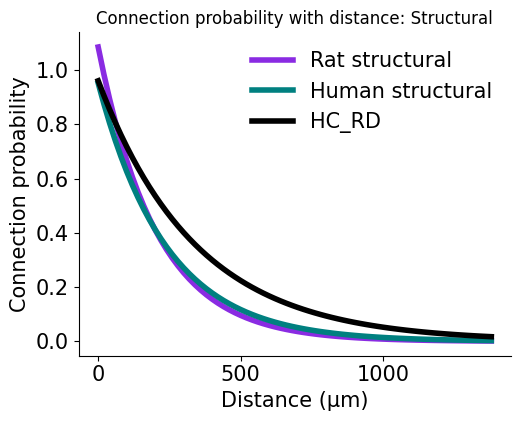

In [33]:
fig = plt.figure(figsize=(5.58, 4.2))
ax0 = plt.subplot()

ax0.plot(x_vector, results["Structural_rat"], color ='blueviolet', linestyle ='solid', linewidth = 4, label='Rat structural')
ax0.plot(x_vector, results["Structural_human"], color = 'teal', linestyle ='solid', linewidth = 4, label= 'Human structural')
ax0.plot(x_vector, results["HC_RD"], color = 'black', linestyle ='solid', linewidth = 4, label= 'HC_RD')

ax0.tick_params(axis='x', labelsize=15)
ax0.tick_params(axis='y', labelsize=15)
ax0.title.set_text('Connection probability with distance: Structural')
ax0.set_ylabel('Connection probability', fontsize=15)
ax0.set_xlabel('Distance (µm)', fontsize=15)
ax0.spines[['right', 'top']].set_visible(False)
ax0.legend(fontsize=15, frameon=False)
fig.savefig('connectionProbability_structural.svg', transparent=True, bbox_inches='tight')

#### Connection probability vs distance: functional against other prunings

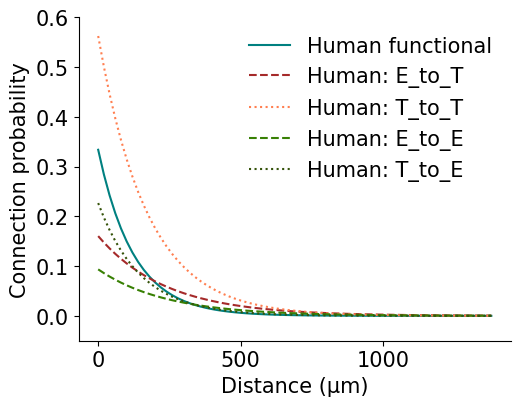

In [34]:
## HUMAN

fig = plt.figure(figsize=(5.58, 4.2))
ax0 = plt.subplot(111)

ax0.plot(x_vector, results["Functional_human"], color = 'teal', linestyle ='solid', label= 'Human functional')
ax0.plot(x_vector, results["E_to_T_human"], color = 'brown', linestyle ='dashed', label= 'Human: E_to_T')
ax0.plot(x_vector, results["T_to_T_human"], color = 'coral', linestyle ='dotted', label= 'Human: T_to_T')
ax0.plot(x_vector, results["E_to_E_human"], color = '#388004', linestyle ='dashed', label= 'Human: E_to_E')
ax0.plot(x_vector, results["T_to_E_human"], color = '#35530a', linestyle ='dotted', label= 'Human: T_to_E')

ax0.tick_params(axis='x', labelsize=15)
ax0.tick_params(axis='y', labelsize=15)
ax0.set_ylim(- 0.05, 0.6)

#ax0.title.set_text('Connection probability with distance')
ax0.set_ylabel('Connection probability', fontsize=15)
ax0.set_xlabel('Distance (µm)', fontsize=15)
ax0.spines[['right', 'top']].set_visible(False)
ax0.legend(fontsize=15, frameon=False)
fig.savefig('connectionProbability_Distance_Allprunings_functional_HUMAN.svg', transparent=True, bbox_inches='tight')

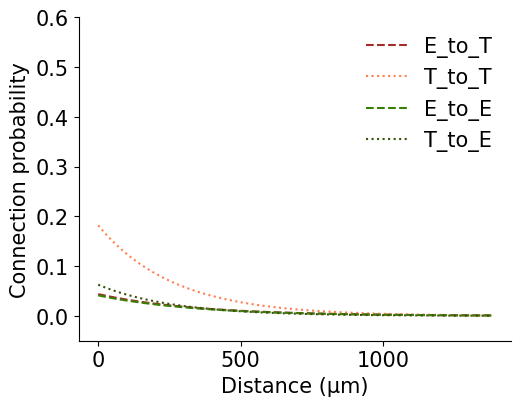

In [35]:
## MODEL

fig = plt.figure(figsize=(5.58, 4.2))
ax0 = plt.subplot(111)

ax0.plot(x_vector, results["E_to_T_HC_RD"], color = 'brown', linestyle ='dashed', label= 'E_to_T')
ax0.plot(x_vector, results["T_to_T_HC_RD"], color = 'coral', linestyle ='dotted', label= 'T_to_T')
ax0.plot(x_vector, results["E_to_E_HC_RD"], color = '#388004', linestyle ='dashed', label= 'E_to_E')
ax0.plot(x_vector, results["T_to_E_HC_RD"], color = '#35530a', linestyle ='dotted', label= 'T_to_E')


ax0.tick_params(axis='x', labelsize=15)
ax0.tick_params(axis='y', labelsize=15)
ax0.set_ylim(- 0.05, 0.6)


#ax0.title.set_text('Connection probability with distance')
ax0.set_ylabel('Connection probability', fontsize=15)
ax0.set_xlabel('Distance (µm)', fontsize=15)
ax0.spines[['right', 'top']].set_visible(False)
ax0.legend(fontsize=15, frameon=False)
fig.savefig('connectionProbability_Distance_Allprunings_functional_MODEL.svg', transparent=True, bbox_inches='tight')

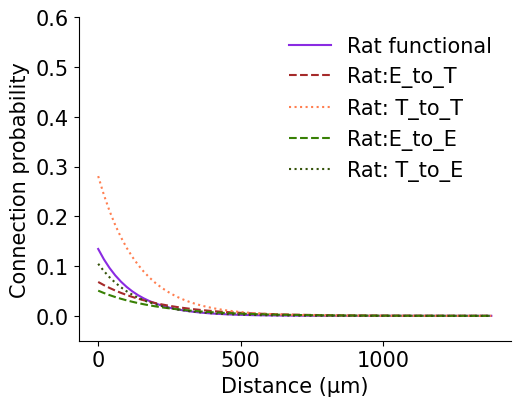

In [36]:
# RAT

fig = plt.figure(figsize=(5.58, 4.2))
ax0 = plt.subplot(111)

ax0.plot(x_vector, results["Functional_rat"], color ='blueviolet', linestyle ='solid',  label='Rat functional')
ax0.plot(x_vector, results["E_to_T_rat"], color ='brown', linestyle ='dashed',  label='Rat:E_to_T')
ax0.plot(x_vector, results["T_to_T_rat"], color ='coral', linestyle ='dotted', label='Rat: T_to_T')
ax0.plot(x_vector, results["E_to_E_rat"], color ='#388004', linestyle ='dashed',  label='Rat:E_to_E')
ax0.plot(x_vector, results["T_to_E_rat"], color ='#35530a', linestyle ='dotted', label='Rat: T_to_E')

ax0.tick_params(axis='x', labelsize=15)
ax0.tick_params(axis='y', labelsize=15)
ax0.set_ylim(- 0.05, 0.6)

#ax0.title.set_text('Connection probability with distance')
ax0.set_ylabel('Connection probability', fontsize=15)
ax0.set_xlabel('Distance (µm)', fontsize=15)
ax0.spines[['right', 'top']].set_visible(False)
ax0.legend(fontsize=15, frameon=False)
fig.savefig('connectionProbability_Distance_Allprunings_functional_RAT.svg', transparent=True, bbox_inches='tight')

## Extra figures

### compute differences: functional vs pruned

In [37]:
def difference(result1, result2):
    diff = []
    for r1, r2 in zip(result1, result2):
        d = abs(r2 - r1)
        diff.append(d)
    return diff

# Human func - Human pruned
diff_h_func_TtoT = difference(results["Functional_human"], results["T_to_T_human"])
diff_h_func_EtoT = difference(results["Functional_human"], results["E_to_T_human"])
diff_h_func_EtoE = difference(results["Functional_human"], results["E_to_E_human"])
diff_h_func_TtoE = difference(results["Functional_human"], results["T_to_E_human"])

# Human func - Control pruned
diff_h_func_HC_RD_TtoT = difference(results["Functional_human"], results["T_to_T_HC_RD"])
diff_h_func_HC_RD_EtoT = difference(results["Functional_human"], results["E_to_T_HC_RD"])
diff_h_func_HC_RD_EtoE = difference(results["Functional_human"], results["E_to_E_HC_RD"])
diff_h_func_HC_RD_TtoE = difference(results["Functional_human"], results["T_to_E_HC_RD"])

# Rat func - Rat pruned            
diff_r_func_TtoT = difference(results["Functional_rat"], results["T_to_T_rat"])
diff_r_func_EtoT = difference(results["Functional_rat"], results["E_to_T_rat"])
diff_r_func_EtoE = difference(results["Functional_rat"], results["E_to_E_rat"])
diff_r_func_TtoE = difference(results["Functional_rat"], results["T_to_E_rat"])

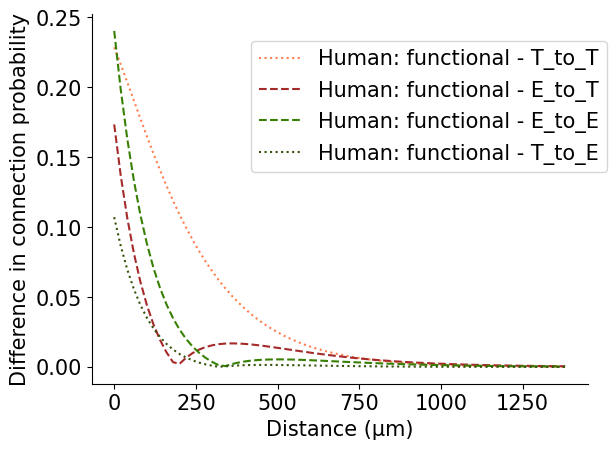

In [38]:
# Human

fig = plt.figure()
ax2 = plt.subplot(111)

ax2.plot(x_vector, diff_h_func_TtoT, color ='coral', linestyle ='dotted', label='Human: functional - T_to_T')
ax2.plot(x_vector, diff_h_func_EtoT, color = 'brown', linestyle ='dashed', label= 'Human: functional - E_to_T')
ax2.plot(x_vector, diff_h_func_EtoE, color = '#388004', linestyle ='dashed', label= 'Human: functional - E_to_E')
ax2.plot(x_vector, diff_h_func_TtoE, color = '#35530a', linestyle ='dotted', label= 'Human: functional - T_to_E')

#ax2.title.set_text('Difference: human - rat')
ax2.tick_params(axis='x', labelsize=15)
ax2.tick_params(axis='y', labelsize=15)
ax2.set_ylabel('Difference in connection probability', fontsize=15)
ax2.set_xlabel('Distance (µm)', fontsize=15)
ax2.spines[['right', 'top']].set_visible(False)
ax2.legend(loc='center left', bbox_to_anchor=(0.3, 0.75), fontsize=15)
fig.savefig('Difference_connectionProbability_Differences_humanfunc_pruned.pdf', transparent=True, bbox_inches='tight')

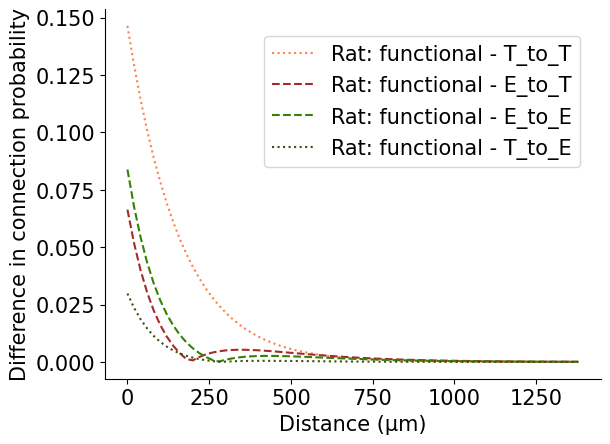

In [39]:
# Rat
fig = plt.figure()
ax2 = plt.subplot(111)

ax2.plot(x_vector, diff_r_func_TtoT, color ='coral', linestyle ='dotted', label='Rat: functional - T_to_T')
ax2.plot(x_vector, diff_r_func_EtoT, color = 'brown', linestyle ='dashed', label= 'Rat: functional - E_to_T')
ax2.plot(x_vector, diff_r_func_EtoE, color = '#388004', linestyle ='dashed', label= 'Rat: functional - E_to_E')
ax2.plot(x_vector, diff_r_func_TtoE, color = '#35530a', linestyle ='dotted', label= 'Rat: functional - T_to_E')

#ax2.title.set_text('Difference: human - rat')
ax2.tick_params(axis='x', labelsize=15)
ax2.tick_params(axis='y', labelsize=15)
ax2.set_ylabel('Difference in connection probability', fontsize=15)
ax2.set_xlabel('Distance (µm)', fontsize=15)
ax2.spines[['right', 'top']].set_visible(False)
ax2.legend(loc='center left', bbox_to_anchor=(0.3, 0.75), fontsize=15)
fig.savefig('Difference_connectionProbability_Differences_Ratfunc_pruned.pdf', transparent=True, bbox_inches='tight')

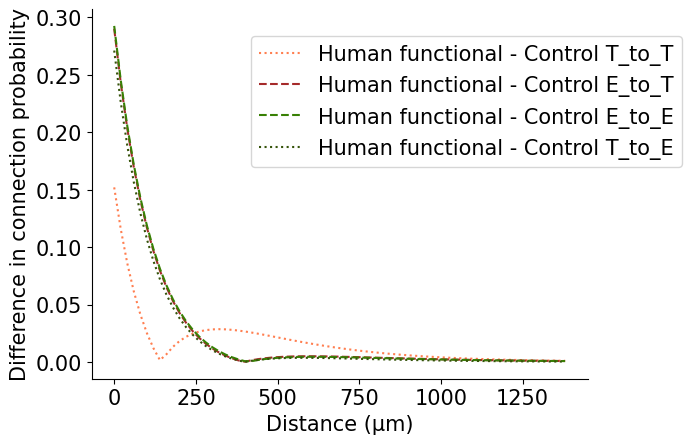

In [41]:
# Control
# Rat
fig = plt.figure()
ax2 = plt.subplot(111)

ax2.plot(x_vector, diff_h_func_HC_RD_TtoT, color ='coral', linestyle ='dotted', label='Human functional - Control T_to_T')
ax2.plot(x_vector, diff_h_func_HC_RD_EtoT, color = 'brown', linestyle ='dashed', label= 'Human functional - Control E_to_T')
ax2.plot(x_vector, diff_h_func_HC_RD_EtoE, color = '#388004', linestyle ='dashed', label= 'Human functional - Control E_to_E')
ax2.plot(x_vector, diff_h_func_HC_RD_TtoE, color = '#35530a', linestyle ='dotted', label= 'Human functional - Control T_to_E')

#ax2.title.set_text('Difference: human - rat')
ax2.tick_params(axis='x', labelsize=15)
ax2.tick_params(axis='y', labelsize=15)
ax2.set_ylabel('Difference in connection probability', fontsize=15)
ax2.set_xlabel('Distance (µm)', fontsize=15)
ax2.spines[['right', 'top']].set_visible(False)
ax2.legend(loc='center left', bbox_to_anchor=(0.3, 0.75), fontsize=15)
fig.savefig('Difference_connectionProbability_Differences_Controlfunc_pruned.pdf', transparent=True, bbox_inches='tight')

### Touch count along distance

In [77]:
# transform target columns in dictionaries
def safe_eval(x):
    return eval(x, {"array": np.array, "np": np})

for cn in circuit_name_list:
    # Apply it to the column
    data[cn][0] = safe_eval(data[cn][0])

/var/folders/jl/cqjntb9j42783g5l8cnlcv0m0000gn/T/ipykernel_8508/4134836065.py:7: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  data[cn][0] = safe_eval(data[cn][0])


In [80]:
# Create dictionary with lists to be used in plots
plot_counts = {}

plot_counts['dist_bins_human'] = data['Structural_human'][0]['dist_bins'] # same for all human and control matrices
plot_counts['count_all_human'] = data['Structural_human'][0]['count_all'] # same for all human and control matrices
plot_counts['dist_bins_rat'] = data['Structural_rat'][0]['dist_bins'] # same for all rat matrices
plot_counts['count_all_rat'] = data['Structural_rat'][0]['count_all'] # same for all rat matrices

for cn in circuit_name_list:
    plot_counts[cn] = data[cn][0]['count_conn']

#### Human structural, human functional vs control

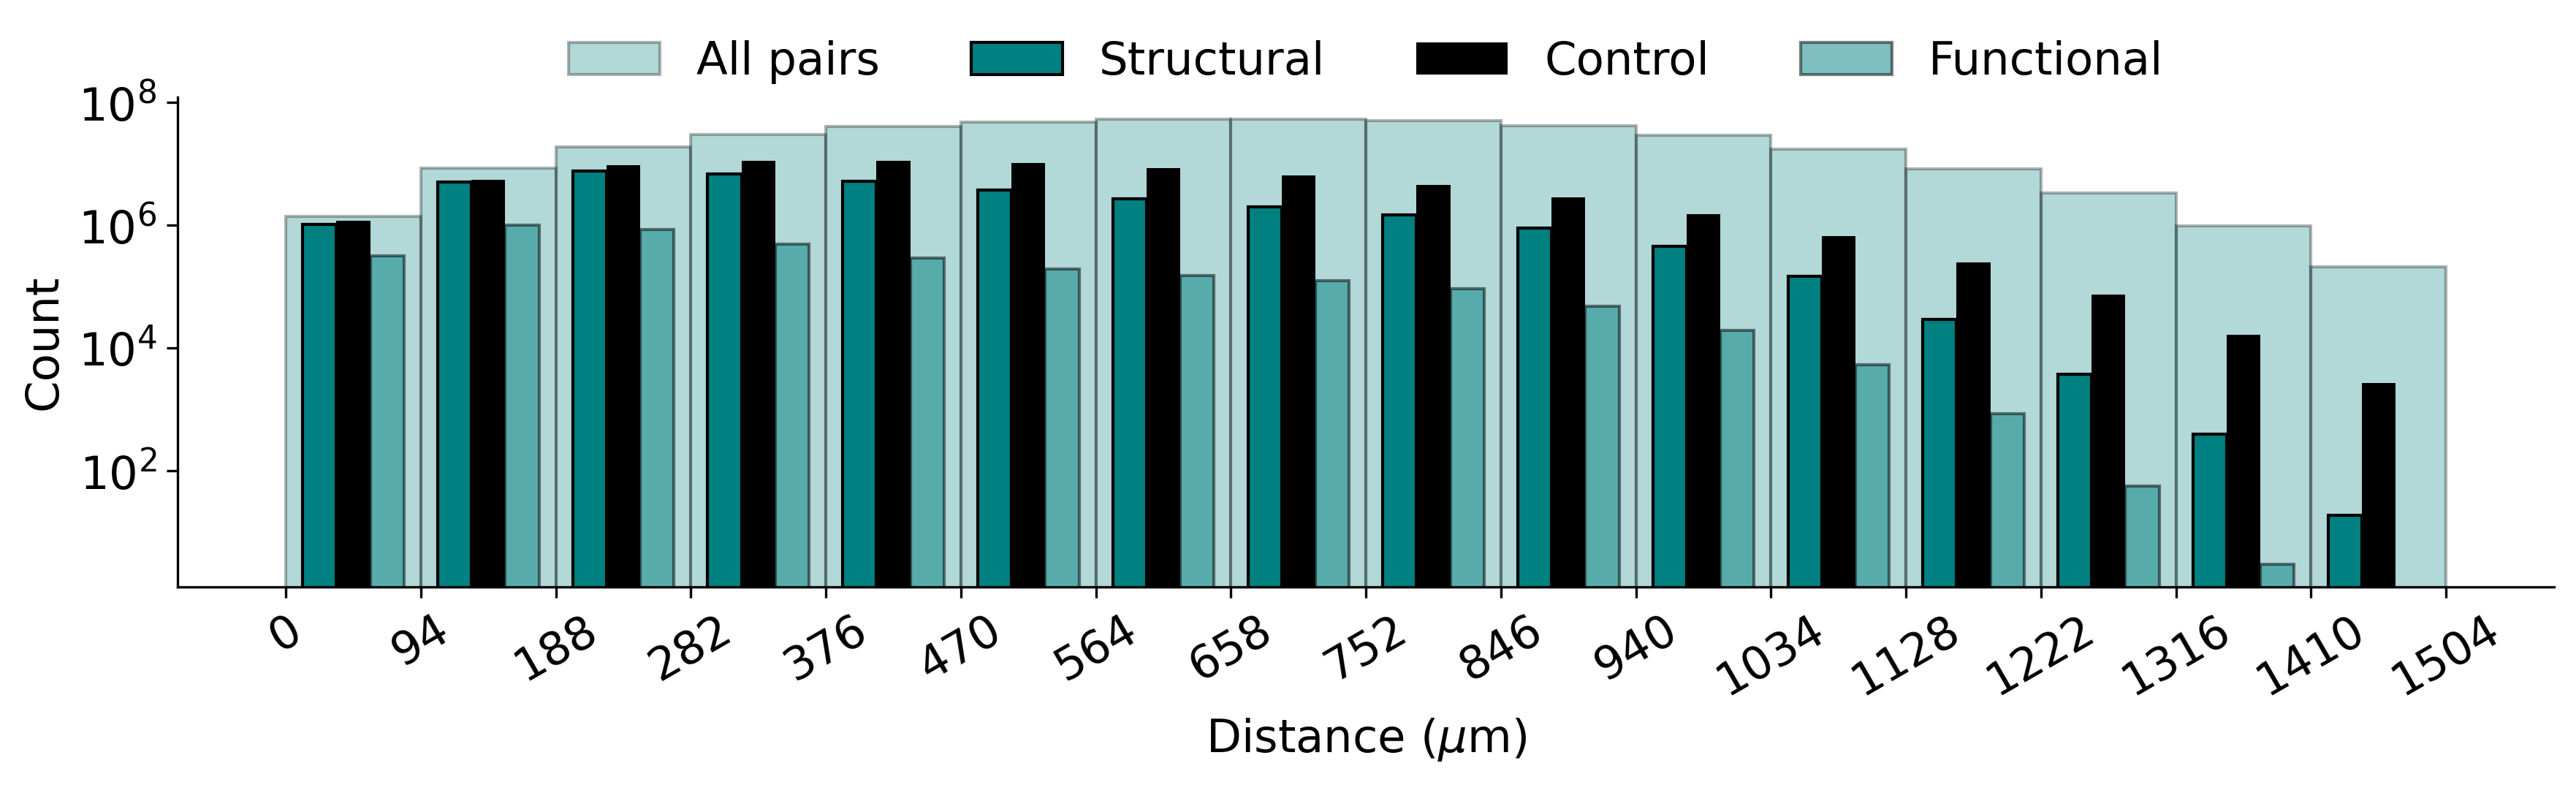

In [81]:
# Data counts
bin_offset = 0.5 * np.diff(dist_bins[:2])[0]

plt.rcParams.update({'font.size': 15})
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.spines.top'] = False

plt.figure(figsize=(12, 4), dpi=300)

plt.bar(dist_bins[:-1] + bin_offset, plot_counts['count_all_human'], width=2.0 * bin_offset, alpha=0.3, color = 'teal', edgecolor='k', label='All pairs')
plt.bar(dist_bins[:-1] + bin_offset - bin_offset/2, plot_counts['Structural_human'], width=0.5 * bin_offset, color = 'teal', edgecolor='k',  label='Structural')
plt.bar(dist_bins[:-1] + bin_offset, plot_counts['HC_RD'], width=0.5 * bin_offset, color = 'black', label='Control')
plt.bar(dist_bins[:-1] + bin_offset + bin_offset/2, plot_counts['Functional_human'], width=0.5 * bin_offset, alpha=0.5, color = 'teal', edgecolor='k', label='Functional')

plt.gca().set_yscale('log')
plt.xticks(dist_bins, rotation=30)
#plt.yticks(c, fontsize=15)
#plt.grid()
plt.xlabel('Distance ($\\mu$m)')
plt.ylabel('Count')
#plt.title(f'Distance-dependent connection counts. Human structural vs human control based on rat data')
plt.legend(loc='upper center',bbox_to_anchor=(0.5, 1.2),ncol=4, frameon=False)
plt.tight_layout()
plt.savefig('DistDepend_HumanSt_HumanFun_HumanControl.svg')

#### Human functional vs all prunings

/var/folders/jl/cqjntb9j42783g5l8cnlcv0m0000gn/T/ipykernel_8508/2702562923.py:23: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


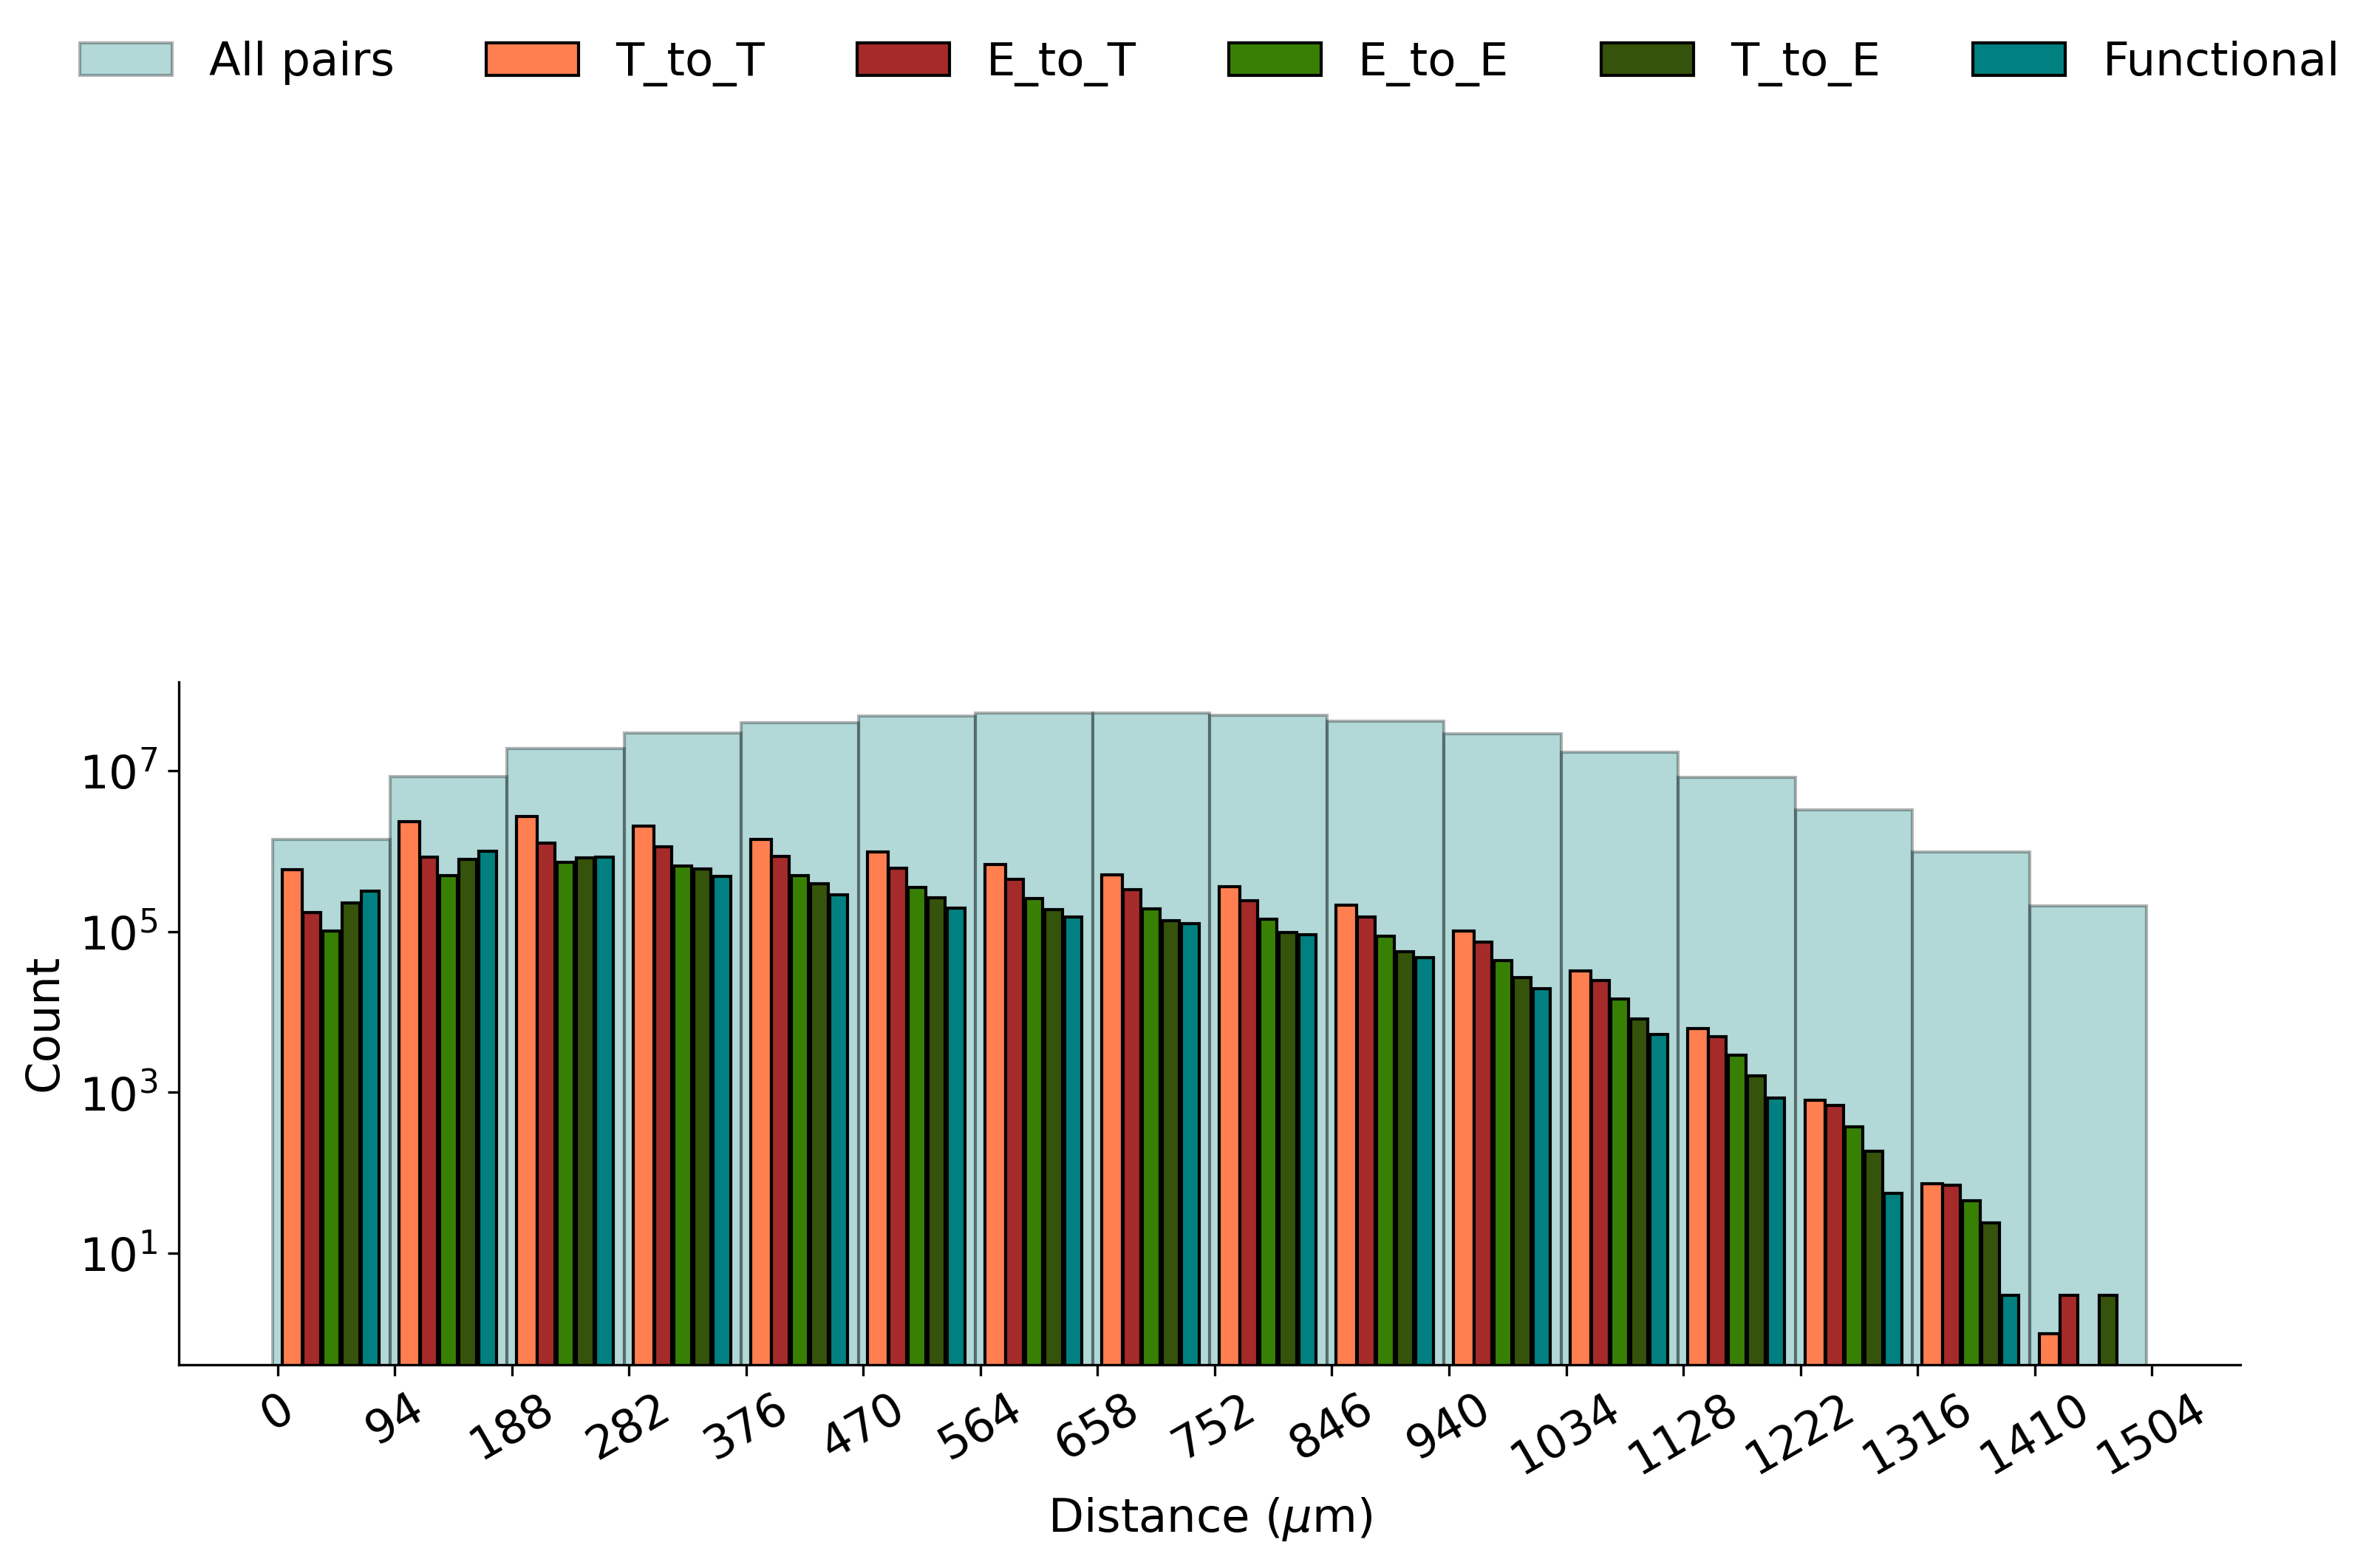

In [167]:
#plt.rcParams.update({'font.size': 15})
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.spines.top'] = False

plt.figure(figsize=(12, 4), dpi=300)

plt.bar(dist_bins[:-1] + bin_offset-4., plot_counts['count_all_human'], width=2.0 * bin_offset, alpha=0.3, color = 'teal', edgecolor='k', label='All pairs')
plt.bar(dist_bins[:-1] + bin_offset/4, plot_counts['T_to_T_human'], width=0.35 * bin_offset, color = 'coral', edgecolor='k', label='T_to_T')
plt.bar(dist_bins[:-1] + bin_offset/4 + bin_offset/3, plot_counts['E_to_T_human'], width=0.3 * bin_offset, color = 'brown', edgecolor='k', label='E_to_T')
plt.bar(dist_bins[:-1] + bin_offset/4 + 2*bin_offset/3, plot_counts['E_to_E_human'], width=0.3 * bin_offset, color = '#388004', edgecolor='k', label='E_to_E')
plt.bar(dist_bins[:-1] + bin_offset/4 + 3*bin_offset/3, plot_counts['T_to_E_human'], width=0.3 * bin_offset, color = '#35530a', edgecolor='k', label='T_to_E')
plt.bar(dist_bins[:-1] + bin_offset/4 + 4*bin_offset/3, plot_counts['Functional_human'], width=0.3 * bin_offset, color = 'teal', edgecolor='k',  label='Functional')


plt.gca().set_yscale('log')
plt.xticks(dist_bins, rotation=30)
#plt.yticks(c, fontsize=15)
#plt.grid()
plt.xlabel('Distance ($\\mu$m)')
plt.ylabel('Count')
#plt.title(f'Distance-dependent connection counts. Human structural vs human control based on rat data')
plt.legend(loc='upper center', bbox_to_anchor=(0.5, 2.), ncol=6, frameon=False)
plt.tight_layout()
plt.savefig('DistDepend_HumanFun_HumanAllPrun.svg')

#### Control vs all control prunings and human functional

/var/folders/jl/cqjntb9j42783g5l8cnlcv0m0000gn/T/ipykernel_8508/3744656748.py:22: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


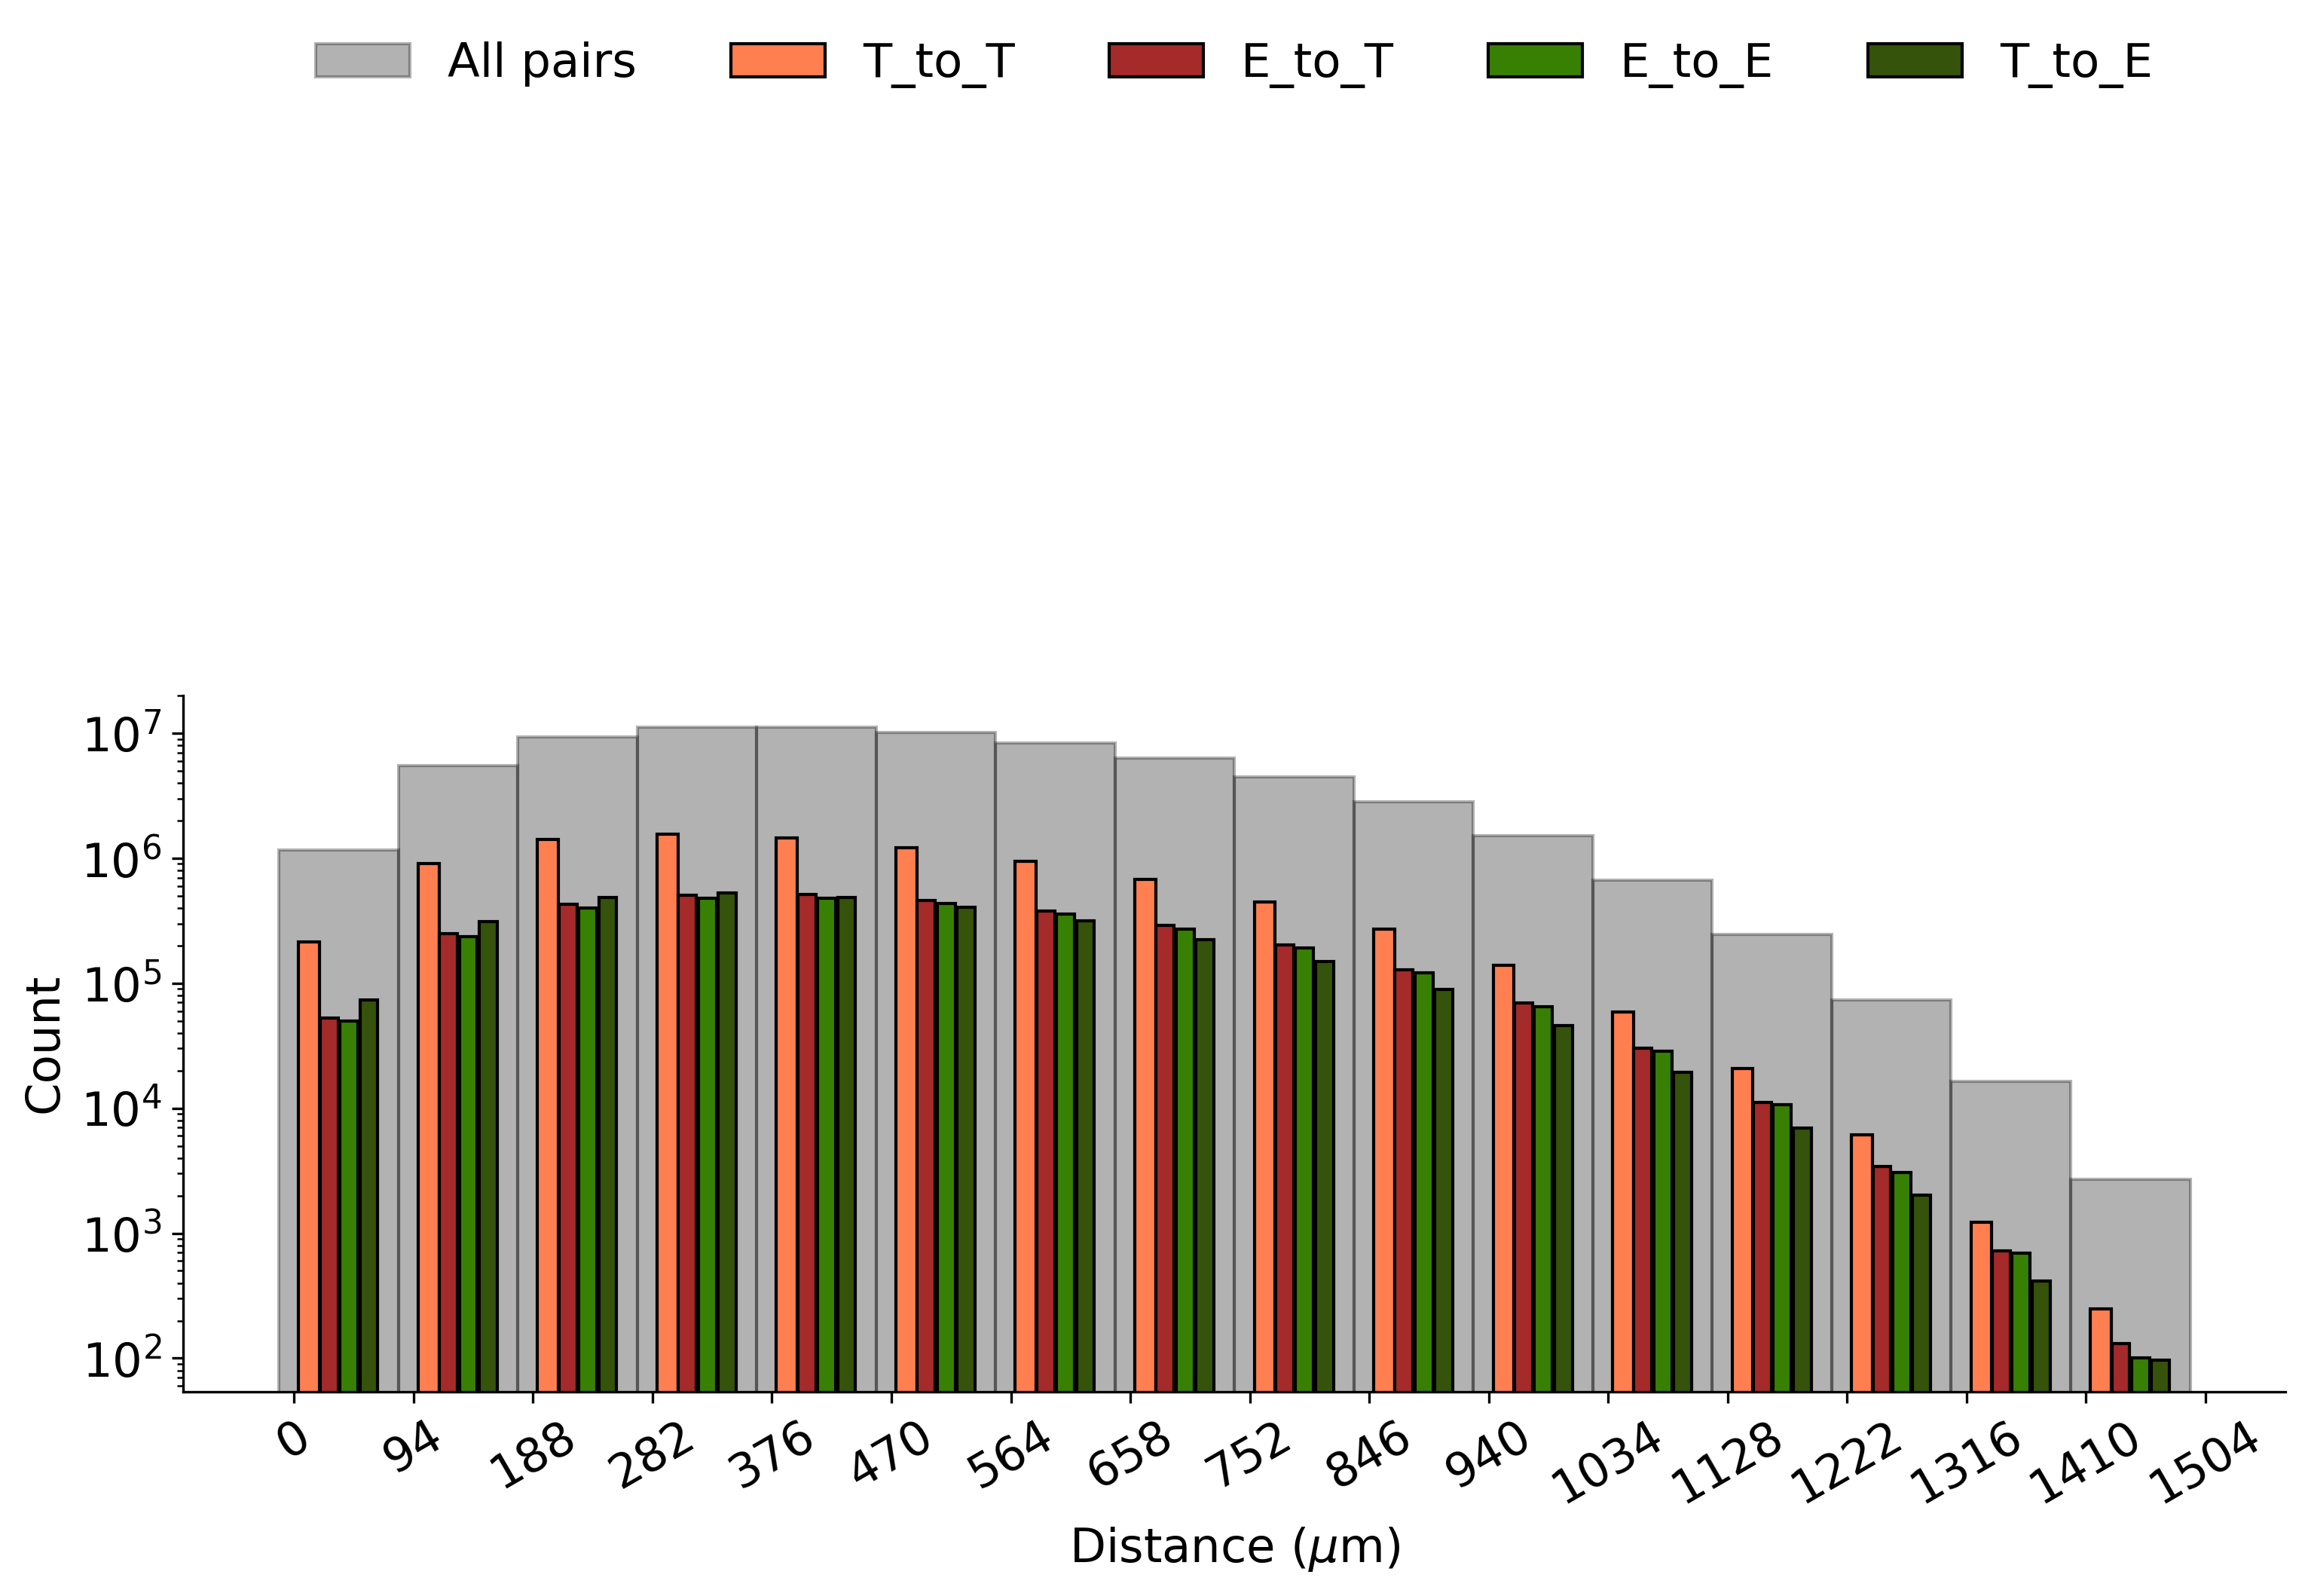

In [175]:
# Control
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.spines.top'] = False

plt.figure(figsize=(12, 4), dpi=300)

plt.bar(dist_bins[:-1] + bin_offset-12., plot_counts['HC_RD'], width=2.0 * bin_offset, alpha=0.3, color = 'black', edgecolor='k', label='All pairs')
plt.bar(dist_bins[:-1] + bin_offset/4, plot_counts['T_to_T_HC_RD'], width=0.35 * bin_offset, color = 'coral', edgecolor='k', label='T_to_T')
plt.bar(dist_bins[:-1] + bin_offset/4 + bin_offset/3, plot_counts['E_to_T_HC_RD'], width=0.3 * bin_offset, color = 'brown', edgecolor='k', label='E_to_T')
plt.bar(dist_bins[:-1] + bin_offset/4 + 2*bin_offset/3, plot_counts['E_to_E_HC_RD'], width=0.3 * bin_offset, color = '#388004', edgecolor='k', label='E_to_E')
plt.bar(dist_bins[:-1] + bin_offset/4 + 3*bin_offset/3, plot_counts['T_to_E_HC_RD'], width=0.3 * bin_offset, color = '#35530a', edgecolor='k', label='T_to_E')


plt.gca().set_yscale('log')
plt.xticks(dist_bins, rotation=30)
#plt.yticks(c, fontsize=15)
#plt.grid()
plt.xlabel('Distance ($\\mu$m)')
plt.ylabel('Count')
#plt.title(f'Distance-dependent connection counts. Human structural vs human control based on rat data')
plt.legend(loc='upper center', bbox_to_anchor=(0.5, 2.), ncol=6, frameon=False)
plt.tight_layout()
plt.savefig('DistDepend_Control_ControlAllPrun.svg')

#### Rat functional vs all rat prunings 

/var/folders/jl/cqjntb9j42783g5l8cnlcv0m0000gn/T/ipykernel_8508/16110701.py:23: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


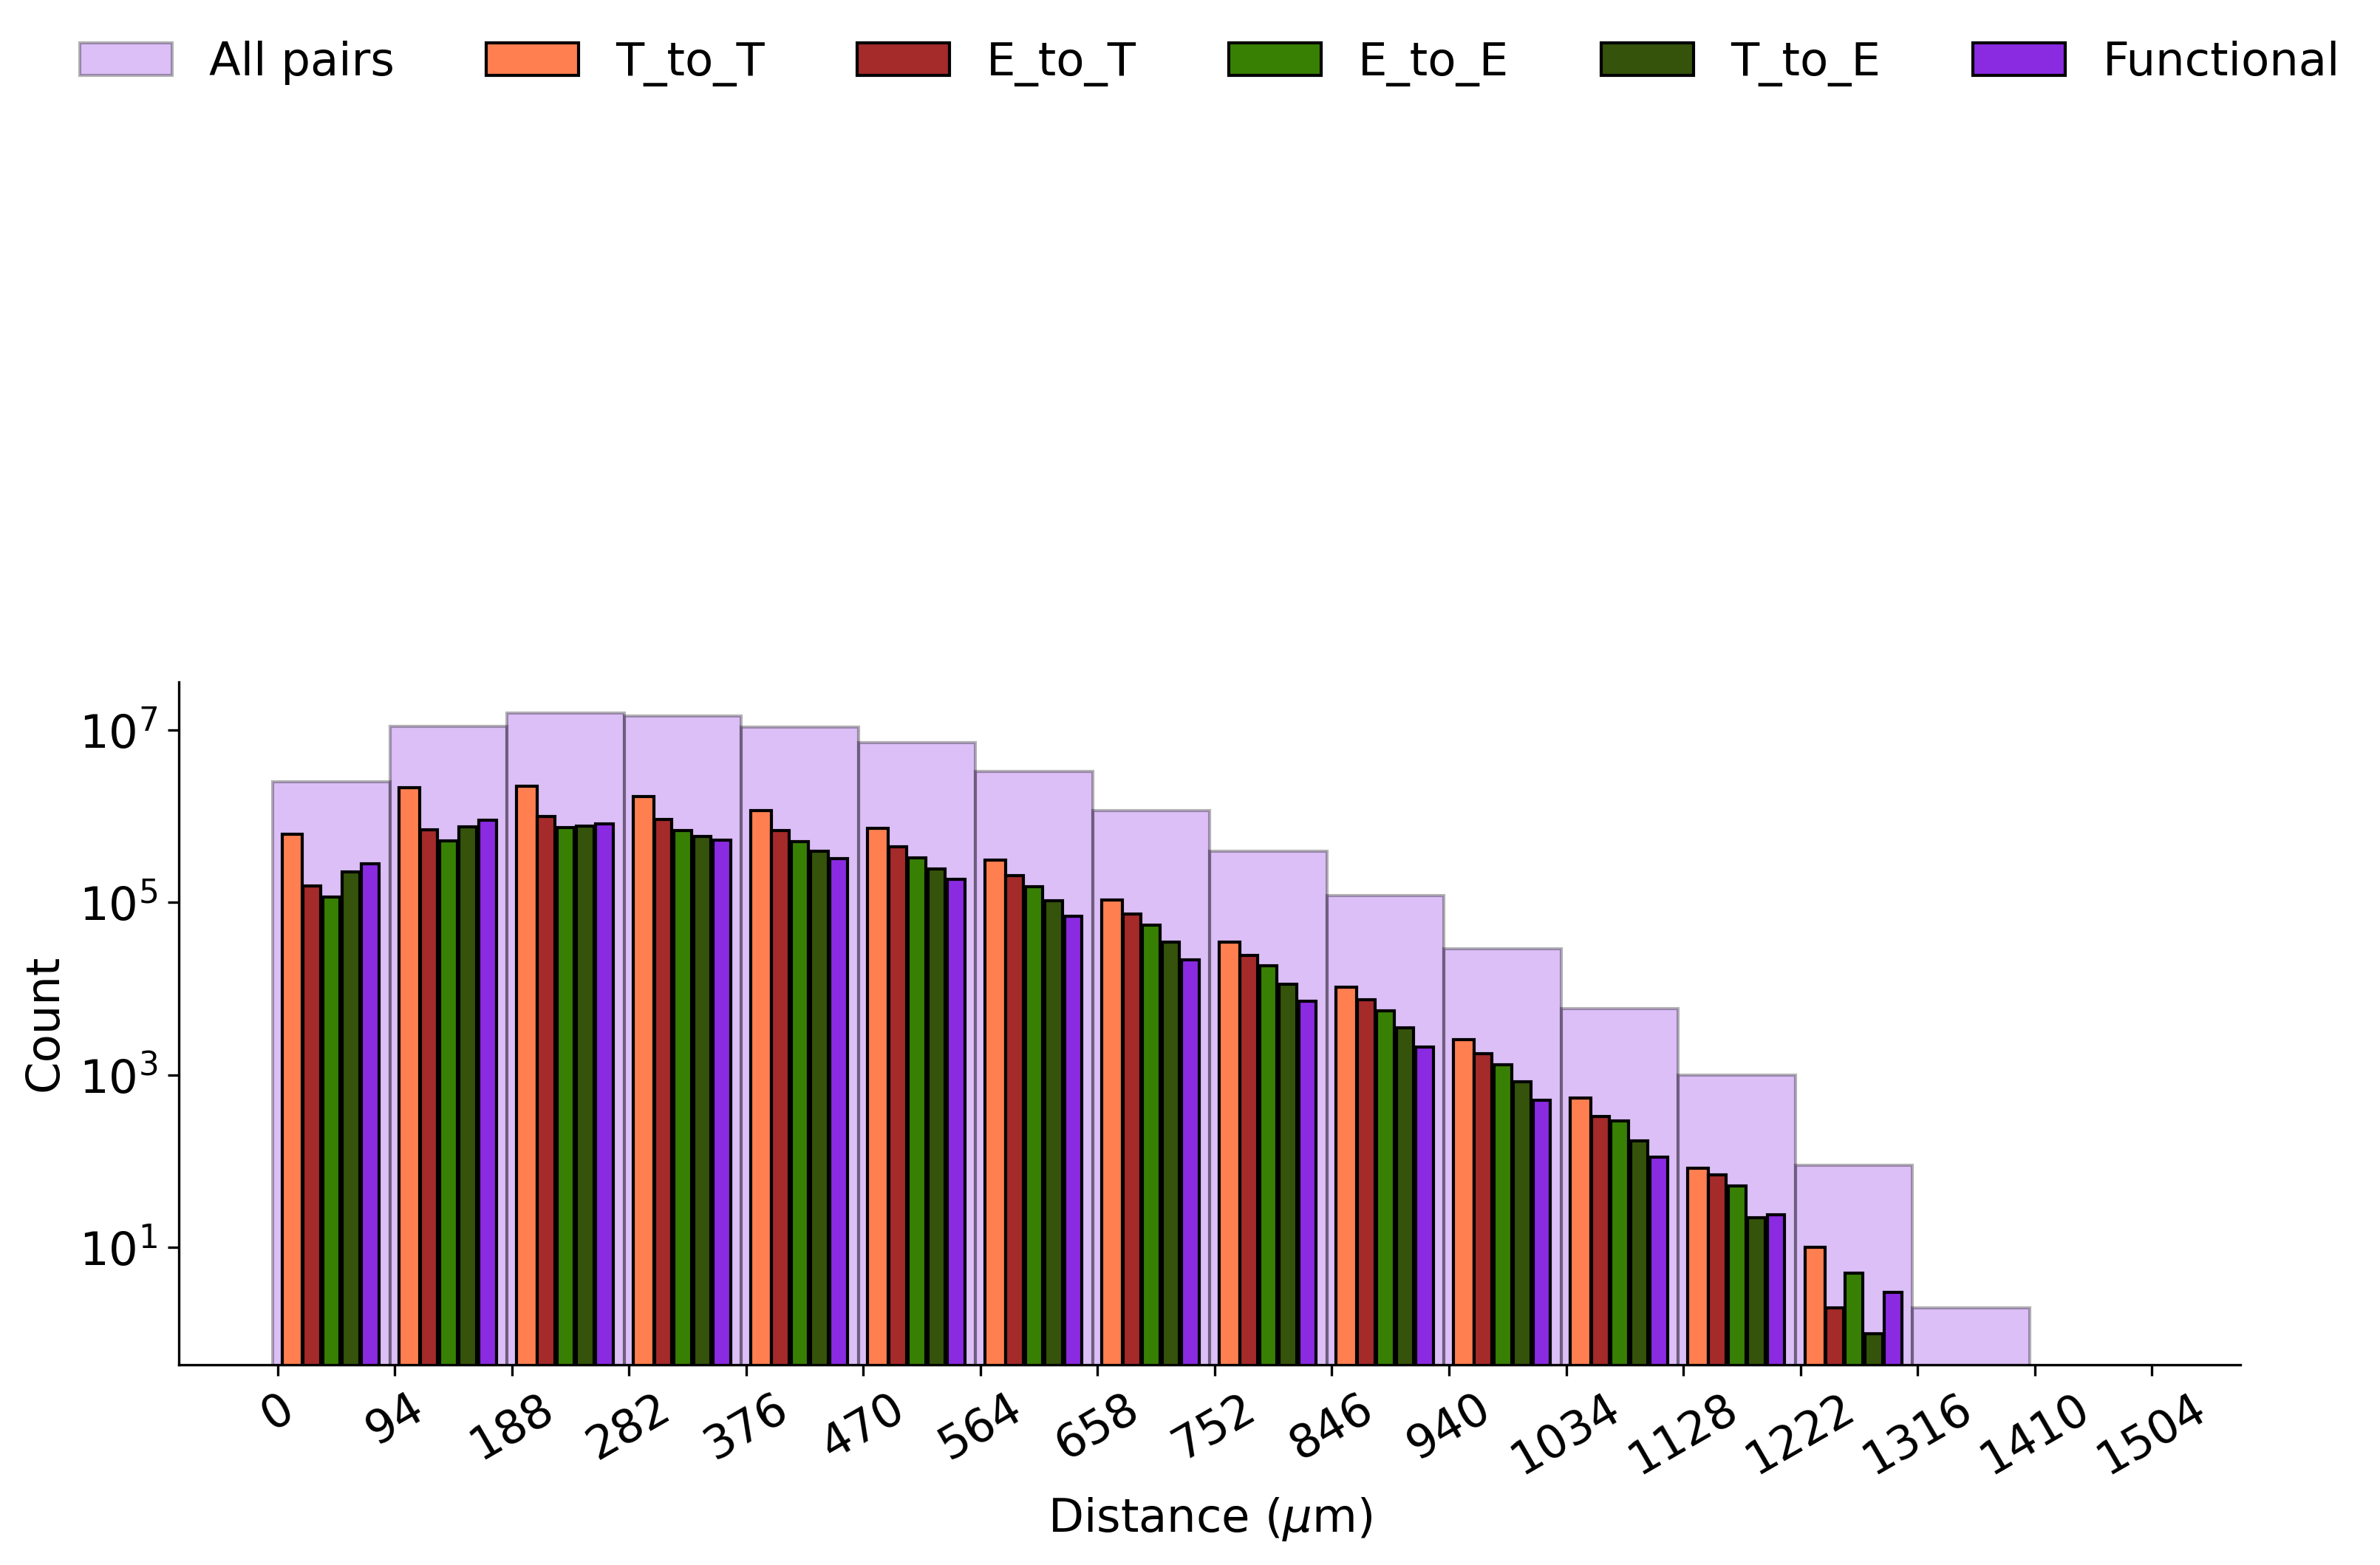

In [176]:
# Rat
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.spines.top'] = False

plt.figure(figsize=(12, 4), dpi=300)

plt.bar(dist_bins[:-1] + bin_offset-4., plot_counts['Structural_rat'], width=2.0 * bin_offset, alpha=0.3, color = 'blueviolet', edgecolor='k', label='All pairs')
plt.bar(dist_bins[:-1] + bin_offset/4, plot_counts['T_to_T_rat'], width=0.35 * bin_offset, color = 'coral', edgecolor='k', label='T_to_T')
plt.bar(dist_bins[:-1] + bin_offset/4 + bin_offset/3, plot_counts['E_to_T_rat'], width=0.3 * bin_offset, color = 'brown', edgecolor='k', label='E_to_T')
plt.bar(dist_bins[:-1] + bin_offset/4 + 2*bin_offset/3, plot_counts['E_to_E_rat'], width=0.3 * bin_offset, color = '#388004', edgecolor='k', label='E_to_E')
plt.bar(dist_bins[:-1] + bin_offset/4 + 3*bin_offset/3, plot_counts['T_to_E_rat'], width=0.3 * bin_offset, color = '#35530a', edgecolor='k', label='T_to_E')
plt.bar(dist_bins[:-1] + bin_offset/4 + 4*bin_offset/3, plot_counts['Functional_rat'], width=0.3 * bin_offset, color = 'blueviolet', edgecolor='k',  label='Functional')


plt.gca().set_yscale('log')
plt.xticks(dist_bins, rotation=30)
#plt.yticks(c, fontsize=15)
#plt.grid()
plt.xlabel('Distance ($\\mu$m)')
plt.ylabel('Count')
#plt.title(f'Distance-dependent connection counts. Human structural vs human control based on rat data')
plt.legend(loc='upper center', bbox_to_anchor=(0.5, 2.), ncol=6, frameon=False)
plt.tight_layout()
plt.savefig('DistDepend_Rat_RatAllPrun.svg')